In [ ]:
import numpy as np
from collections import defaultdict
import gymnasium as gym

class BlackjackQLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.95, epsilon=1.0, epsilon_decay=0.99999, min_epsilon=0.01):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
        return action

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        self.q_values[state][action] += self.lr * (target_q - current_q)

class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5):
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Tuple(
            (gym.spaces.Discrete(32), gym.spaces.Discrete(11), gym.spaces.Discrete(2))
        )
        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.running_count = 0
        self.betting_unit = 1
        self.money = 50
        self.current_bet = 1
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action)
        if action:
            self.player.append(self.draw_card(self.np_random))
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        self.money += reward * self.current_bet
        return self._get_obs(), reward, terminated, self.money

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], int(self.usable_ace(self.player)))


    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        self.running_count = 0
        return self.new_round()

    def new_round(self):
        self.dealer = self.draw_hand(self.np_random)
        self.player = self.draw_hand(self.np_random)
        return self._get_obs()

    def draw_card(self, np_random):
        if len(self.deck) == 0:
            print("Deck is empty! Reshuffling...")
            self.deck = self.original_deck.copy()  # Reshuffle if empty
        card_index = np_random.choice(len(self.deck))
        card = self.deck[card_index]
        if card in [1, 10]:
            self.running_count -= 1
        elif 2 <= card <= 6:
            self.running_count += 1
        self.deck.pop(card_index)
        return card


    def draw_hand(self, np_random):
        return [self.draw_card(np_random), self.draw_card(np_random)]

    def getRemainingDecks(self):
        return round(len(self.deck) / 52 * 2) / 2

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]

# def train_agent(env, agent, num_episodes):
#     for episode in range(num_episodes):
#         if env.getRemainingDecks() < 1 or env.money < 1:
#             state = env.reset()
#         else:
#             state = env.new_round()
#         done = False
#         while not done:
#             action = agent.get_action(state)
#             next_state, reward, done, _ = env.step(action)
#             agent.update(state, action, reward, next_state, done)
#             state = next_state
#         if episode % 10000 == 0:
#             print(f"Episode {episode} completed")

def train_agent(env, agent, num_episodes):
    for episode in range(num_episodes):
        state = env.reset()
        # while env.getRemainingDecks() >= 1 and env.money >= 1:
        #     state = env.new_round()
        #     done = False
        #     while not done:
        #         action = agent.get_action(state)
        #         next_state, reward, done, _ = env.step(action)
        #         agent.update(state, action, reward, next_state, done)
        #         state = next_state
        # if episode % 10000 == 0:
        #     print(f"Episode {episode} completed")

        while env.getRemainingDecks() >= 1 and env.money >= 1:
            state = env.new_round()
            done = False
            while not done:
                action = agent.get_action(state)
                next_state, reward, done, _ = env.step(action)
                agent.update(state, action, reward, next_state, done)
                state = next_state
            if env.money < 1:
                print("Agent lost all money. Resetting.")
                env.reset()
        if episode % 1000 == 0:
            print(f"Episode {episode} completed")


def evaluate_agent(env, agent, num_episodes=10000):
    total_reward = 0
    env.reset()
    for _ in range(num_episodes):
        if env.money < 1:
            print("Agent lost all money. Evaluation stopped.")
            break
        if env.getRemainingDecks() < 1:
            env.deck = env.original_deck.copy()
        else:
            state = env.new_round()
        done = False
        while not done:
            action = np.argmax(agent.q_values[state])
            state, reward, done, _ = env.step(action)
            total_reward += reward
    return total_reward / num_episodes if env.money >= 1 else total_reward / (_ + 1)


In [ ]:
# Create environment and agent
env = BlackjackEnv()
agent = BlackjackQLearningAgent()

# Train the agent
train_agent(env, agent, num_episodes=10000)

# Evaluate the agent
env.reset()
average_reward = evaluate_agent(env, agent)
print(f"Average reward over 10,000 episodes: {average_reward}")

Episode 0 completed


KeyboardInterrupt: 

Deck is empty! Reshuffling...
Deck is empty! Reshuffling...


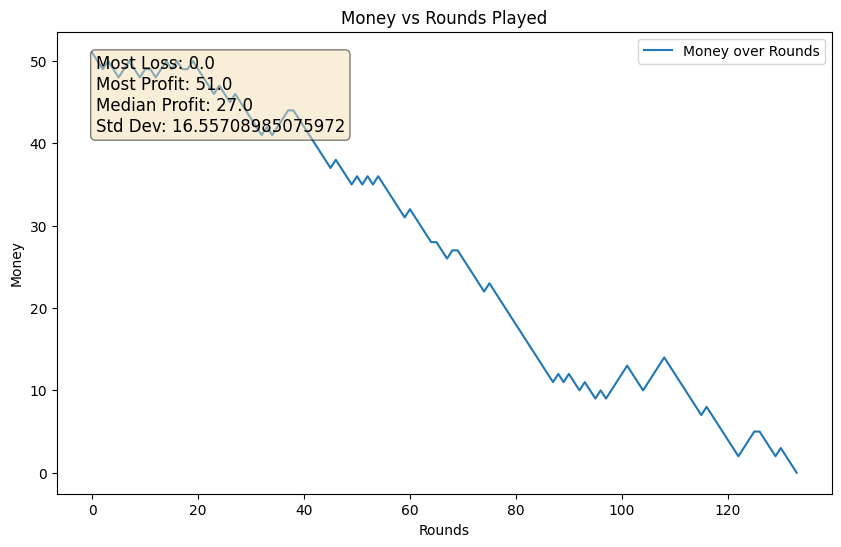

In [ ]:
import matplotlib.pyplot as plt

# Initialize variables to store money history and rounds
money_history = []
rounds = 0

# Reset the environment and set initial money
env.reset()
env.money = 50

# Play rounds until money is depleted
while env.money >= 1:
    done = False
    observation = env.new_round()
    while not done:
        action = env.action_space.sample()
        observation, reward, done, money = env.step(action)
    money_history.append(env.money)
    rounds += 1

# Calculate statistics
most_loss = min(money_history)
most_profit = max(money_history)
median_profit = np.median(money_history)
std_dev = np.std(money_history)


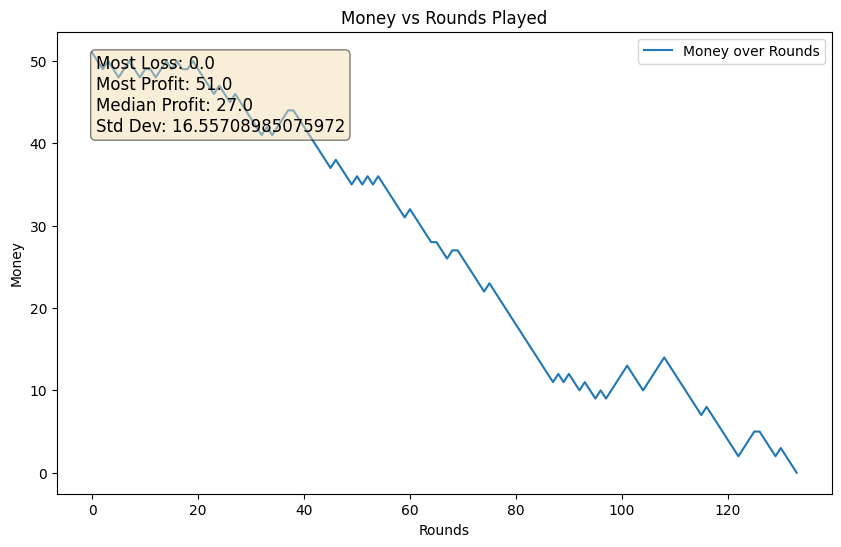

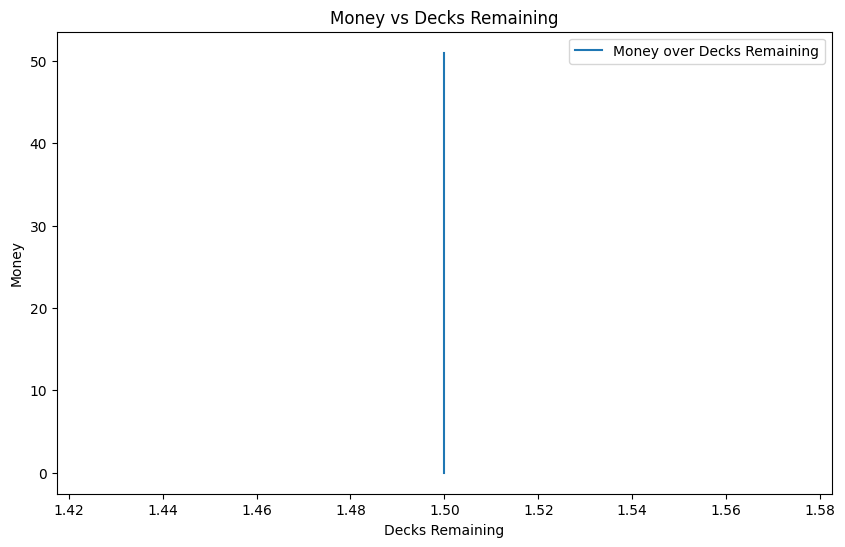

In [10]:
# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(range(rounds), money_history, label='Money over Rounds')
plt.xlabel('Rounds')
plt.ylabel('Money')
plt.title('Money vs Rounds Played')
plt.legend()

# Add statistics box
stats_text = f'Most Loss: {most_loss}\nMost Profit: {most_profit}\nMedian Profit: {median_profit}\nStd Dev: {std_dev}'
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.savefig('money_vs_rounds_QLearning.png', bbox_inches='tight')
plt.show()

# Plot the graph of money vs decks remaining
decks_remaining = [env.getRemainingDecks() for _ in range(rounds)]
plt.figure(figsize=(10, 6))
plt.plot(decks_remaining, money_history, label='Money over Decks Remaining')
plt.xlabel('Decks Remaining')
plt.ylabel('Money')
plt.title('Money vs Decks Remaining')
plt.legend()

# Save the plot
plt.savefig('money_vs_decks_remaining_QLearning.png', bbox_inches='tight')
plt.show()
